In [35]:
import numpy as np
from astropy.io import fits
import matplotlib.pyplot as plt

import sys
sys.path.append('/home/rkievit/masterproject/masterproject/src')

from data_queries import query_extra_data



In [6]:
## Functions

In [87]:
radius = '10as'
method = 'nearest'

rpath = '../../results/'
dpath = '../../../data/' 
xm_all = np.load(rpath+'crossmatch_1as_all_neighbours.npy')
xm_near = np.load(rpath+'crossmatch_1as_best_neighbour_nearest.npy')
xm_bright = np.load(rpath+'crossmatch_1as_best_neighbour_brightest.npy') 

xm = np.load(rpath+f'crossmatch_{radius}_best_neighbour_{method}.npy')

In [17]:
# Get Gaia data
#extra_gdata = ['phot_g_mean_mag', 'pmra', 'pmdec', 'pmra_error', 'pmdec_error']
#xm_all, gdata_all = query_extra_data(xm_all, extra_gdata)
#xm_near, gdata_near = query_extra_data(xm_near, extra_gdata)
#xm_bright, gdata_bright = query_extra_data(xm_bright, extra_gdata)

# Get Hipp data
#extra_hdata = ['hp_mag', 'b_v']
#xm_all, hdata_all = query_extra_data(xm_all, extra_hdata)
#xm_near, hdata_all = query_extra_data(xm_near, extra_hdata)
#xm_bright, hdata_all = query_extra_data(xm_bright, extra_hdata)

INFO: Login to gaia TAP server [astroquery.gaia.core]
OK
INFO: Login to gaia data server [astroquery.gaia.core]
OK
Sending pytable.
Uploaded table 'xm_table'.
INFO: Query finished. [astroquery.utils.tap.core]
Table 'xm_table' deleted.
INFO: Login to gaia TAP server [astroquery.gaia.core]
OK
INFO: Login to gaia data server [astroquery.gaia.core]
OK
Sending pytable.
Uploaded table 'xm_table'.
INFO: Query finished. [astroquery.utils.tap.core]


ValueError: could not broadcast input array from shape (44668,) into shape (116901,)

## Hipparcos Values Matched vs. Unmatched

In [77]:
hipp = fits.open(dpath+'Hipparcos2.fits')[1].data
hip_ids = hipp['hip']

hip_matched = [] # Appending slow but whatever
hip_nomatch = []

for i,hip in enumerate(hip_ids):
    if hip in xm[:,0]:
        hip_matched.append(i)
    else:

        hip_nomatch.append(i)
hip_matched = np.array(hip_matched)
hip_nomatch = np.array(hip_nomatch)

In [84]:
print(f"Number of matched Hipparcos stars: {hip_matched.shape[0]}")
print(f"Number of unmatched Hipparcos stars: {hip_nomatch.shape[0]}")

Number of matched Hipparcos stars: 117812
Number of unmatched Hipparcos stars: 143


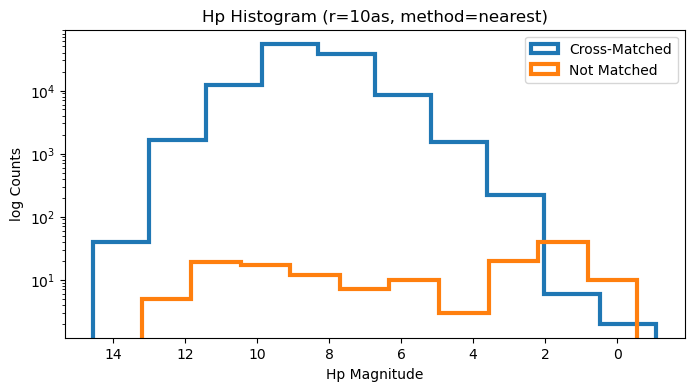

In [80]:
# Compare histograms of magnitude
fig, ax = plt.subplots(1,1, figsize=(8,4))

ax.hist(hipp['hp_mag'][hip_matched], histtype='step', lw=3, log=True, label='Cross-Matched')
ax.hist(hipp['hp_mag'][hip_nomatch], histtype='step', lw=3, log=True, label='Not Matched')
ax.set_xlabel('Hp Magnitude')
ax.set_ylabel('log Counts')
ax.set_title(f"Hp Histogram (r={radius}, method={method})")
ax.invert_xaxis()

plt.legend()
plt.show()

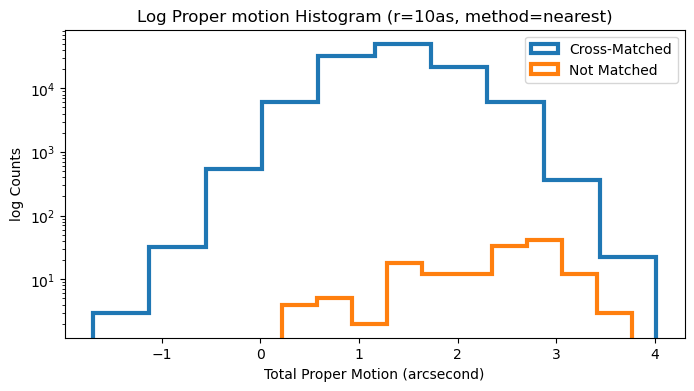

In [82]:
# Compare histogram of proper mitions
pm_matched = np.sqrt((hipp['pm_ra'][hip_matched]**2.) + (hipp['pm_de'][hip_matched]**2))
pm_nomatch = np.sqrt((hipp['pm_ra'][hip_nomatch]**2.) + (hipp['pm_de'][hip_nomatch]**2))

fig, ax = plt.subplots(1,1, figsize=(8,4))

ax.hist(np.log10(pm_matched), histtype='step', lw=3, log=True, label='Cross-Matched')
ax.hist(np.log10(pm_nomatch), histtype='step', lw=3, log=True, label='Not Matched')
ax.set_xlabel('Total Proper Motion (arcsecond)')
ax.set_ylabel('log Counts')
ax.set_title(f"Log Number of matched Hipparcos stars: 117812
Number of unmatched Hipparcos stars: 143

Proper motion Histogram (r={radius}, method={method})")

plt.legend()
plt.show()

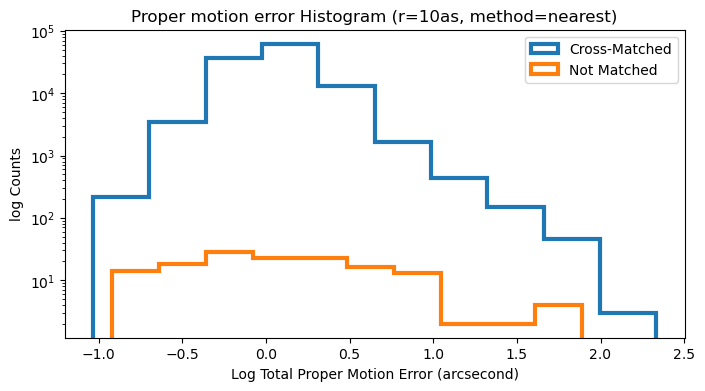

In [83]:
# Compare histogram of proper mitions
e_pm_matched = np.sqrt((hipp['e_pm_ra'][hip_matched]**2.) + (hipp['e_pm_de'][hip_matched]**2))
e_pm_nomatch = np.sqrt((hipp['e_pm_ra'][hip_nomatch]**2.) + (hipp['e_pm_de'][hip_nomatch]**2))

fig, ax = plt.subplots(1,1, figsize=(8,4))

ax.hist(np.log10(e_pm_matched), his
ttype='step', lw=3, log=True, label='Cross-Matched')
ax.hist(np.log10(e_pm_nomatch), histtype='step', lw=3, log=True, label='Not Matched')
ax.set_xlabel('Log Total Proper Motion Error (arcsecond)')

ax.set_ylabel('log Counts')
ax.set_title(f"Proper motion error Histogram (r={radius}, method={method})")

plt.legend()
plt.show()

## Gaia properties of Matched objects

In [ ]:
gaia = fits.open(dpath+'GaiaBaseCat.fits')[1].data

gaia_matched = [] 

for i,source_id in enumerate(gaia['source_id']):
    if source_id in xm[:,1]:
        gaia_matched.append(i)

gaia_matched = np.array(gaia_matched)

In [89]:
fig, ax = plt.subplots(1,1, figsize=(6,6))



FITS_rec([( 498895983697735552,  78.51864764,  72.10596783,  0.37262797, -0.01167932, 0.42987322,  78.5186393 ,  72.10596791, 0.42987279,  0.37262722, -0.01167925, -8.44896386e+00, 0.21675663, 0.27225867, -0.03651706, 12.448798, 1.3214092 ),
          (5727850956699814272, 121.90287833, -11.77536725, -2.1558217 , -5.56010539, 2.43312328, 121.90289347, -11.77532903, 2.43312461, -2.15582374, -5.56011156,  4.53855548e+00, 0.56079725, 0.35262137,  0.11283269, 12.448798, 0.83098507),
          (5871959856985072000, 205.53367502, -57.23771953, -9.71854928, -5.56734984, 1.28528854, 205.53379849, -57.23768126, 1.28528781, -9.7185282 , -5.56736115, -4.71401910e+00, 0.28853187, 0.42419222,  0.01694337, 12.448799, 0.5458517 ),
          ...,
          (4151144444902586368, 270.96502343, -11.36503621,  3.31486083,  4.86413558, 0.99520506, 270.96500019, -11.36506965, 0.99520296,  3.31484721,  4.86411475, -1.76147856e+01, 0.4390558 , 0.34611451,  0.25114155, 13.372266, 1.8997717 ),
          (595509